# LS2001 American Put Replication

This notebook reproduces the Longstaff-Schwartz (2001) American put pricing benchmark and establishes the pricing baseline used by the later Greek notebooks.


## Objective

The goal of this notebook is to confirm that the extracted `src/` implementation reproduces the paper's pricing behavior closely enough to serve as the baseline for the Greek experiments. The comparison focuses on the American price and the implied early-exercise premium.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent
src_root = project_root / "src"
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

figure_dir = project_root / "assets" / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)
plt.style.use("seaborn-v0_8-whitegrid")

from lsmc_greeks.pricer import LSMCConfig, bs_european_put, lsm_american_put

def save_figure(fig, filename):
    path = figure_dir / filename
    fig.savefig(path, dpi=220, bbox_inches="tight")
    return path


## LS2001 Setup

We follow the 1D American put example from the paper with 50 exercise dates per year and the weighted Laguerre basis used in the Longstaff-Schwartz continuation regression.


In [2]:
config = LSMCConfig(n_steps_per_year=50, n_paths=100_000, basis_degree=2, seed=42)
strike = 40.0
rate = 0.06

param_grid = [
    (36, 0.20, 1), (36, 0.20, 2),
    (36, 0.40, 1), (36, 0.40, 2),
    (38, 0.20, 1), (38, 0.20, 2),
    (38, 0.40, 1), (38, 0.40, 2),
    (40, 0.20, 1), (40, 0.20, 2),
    (40, 0.40, 1), (40, 0.40, 2),
    (42, 0.20, 1), (42, 0.20, 2),
    (42, 0.40, 1), (42, 0.40, 2),
    (44, 0.20, 1), (44, 0.20, 2),
    (44, 0.40, 1), (44, 0.40, 2),
]

fd_american = [
    4.478, 4.840, 7.101, 8.508,
    3.250, 3.745, 6.148, 7.670,
    2.314, 2.885, 5.312, 6.920,
    1.617, 2.212, 4.582, 6.248,
    1.110, 1.690, 3.948, 5.647,
]


## Replication Table

The table below compares the LSMC prices to the finite-difference values reported in LS2001 and computes the early-exercise premium using the Black-Scholes European put as the common reference.


In [3]:
rows = []
for index, (spot, sigma, maturity) in enumerate(param_grid):
    result = lsm_american_put(spot=spot, strike=strike, rate=rate, sigma=sigma, maturity=maturity, config=config)
    bs_euro = bs_european_put(spot, strike, rate, sigma, maturity)
    fd_price = fd_american[index]
    fd_ee = fd_price - bs_euro
    lsmc_ee = result.american_price - bs_euro
    rows.append({
        "spot": spot,
        "sigma": sigma,
        "maturity": maturity,
        "fd_price": fd_price,
        "lsmc_price": result.american_price,
        "std_error": result.std_error,
        "bs_euro": bs_euro,
        "fd_ee": fd_ee,
        "lsmc_ee": lsmc_ee,
        "diff_ee": fd_ee - lsmc_ee,
    })

results = pd.DataFrame(rows).round(6)
results


,spot,sigma,maturity,fd_price,lsmc_price,std_error,bs_euro,fd_ee,lsmc_ee,diff_ee
0,36,0.2,1,4.478,4.481491,0.009234,3.844308,0.633692,0.637183,-0.003491
1,36,0.2,2,4.840,4.841744,0.011094,3.763001,1.076999,1.078743,-0.001744
2,36,0.4,1,7.101,7.104790,0.019088,6.711399,0.389601,0.393391,-0.003790
3,36,0.4,2,8.508,8.503069,0.022353,7.700040,0.807960,0.803029,0.004931
4,38,0.2,1,3.250,3.251530,0.009370,2.851932,0.398068,0.399597,-0.001530
5,38,0.2,2,3.745,3.736224,0.010981,2.990557,0.754443,0.745668,0.008776
6,38,0.4,1,6.148,6.142460,0.018370,5.834321,0.313679,0.308139,0.005540
7,38,0.4,2,7.670,7.657679,0.022098,6.978802,0.691198,0.678876,0.012321
8,40,0.2,1,2.314,2.308181,0.008592,2.066401,0.247599,0.241780,0.005819
9,40,0.2,2,2.885,2.871568,0.010493,2.355866,0.529134,0.515701,0.013432


## Summary Diagnostics

The summary below compresses the replication error into a few report-friendly metrics. This is the main quantitative check that the pricing baseline is coherent before moving to Greeks.


In [4]:
abs_diffs = results["diff_ee"].abs()
summary = pd.DataFrame([
    {"metric": "Mean absolute EE difference", "value": abs_diffs.mean()},
    {"metric": "Max absolute EE difference", "value": abs_diffs.max()},
    {"metric": "Rows with |diff| <= 0.01", "value": int((abs_diffs <= 0.01).sum())},
]).round(6)
summary


,metric,value
0,Mean absolute EE difference,0.010229
1,Max absolute EE difference,0.036640
2,Rows with |diff| <= 0.01,12.000000


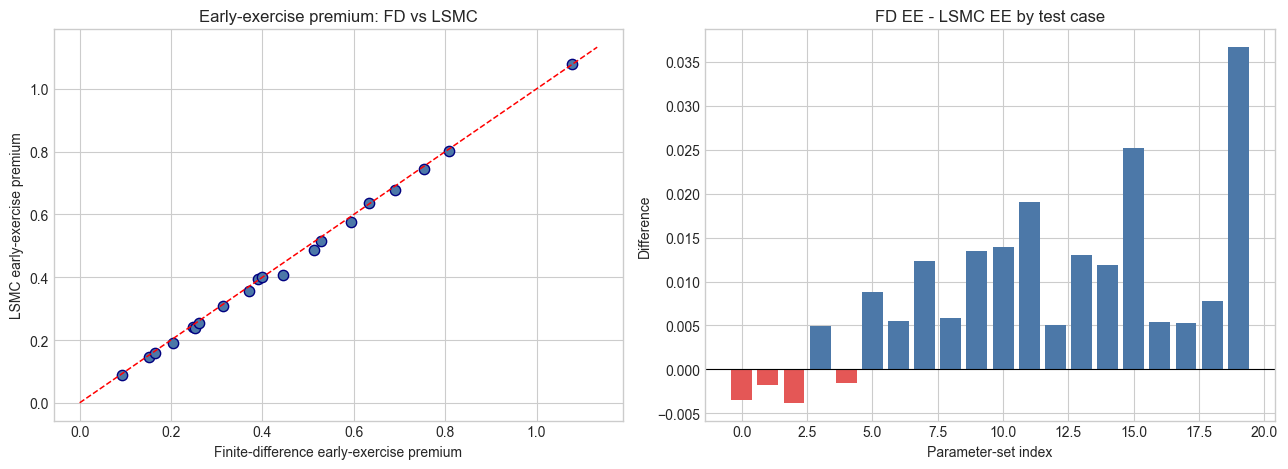

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].scatter(results["fd_ee"], results["lsmc_ee"], color="#4c78a8", edgecolors="navy", s=55)
axis_limit = max(results["fd_ee"].max(), results["lsmc_ee"].max()) * 1.05
axes[0].plot([0, axis_limit], [0, axis_limit], "r--", linewidth=1.1)
axes[0].set_title("Early-exercise premium: FD vs LSMC")
axes[0].set_xlabel("Finite-difference early-exercise premium")
axes[0].set_ylabel("LSMC early-exercise premium")

colors = ["#e45756" if value < 0 else "#4c78a8" for value in results["diff_ee"]]
axes[1].bar(range(len(results)), results["diff_ee"], color=colors)
axes[1].axhline(0.0, color="black", linewidth=0.8)
axes[1].set_title("FD EE - LSMC EE by test case")
axes[1].set_xlabel("Parameter-set index")
axes[1].set_ylabel("Difference")

plt.tight_layout()
save_figure(fig, "ls2001_replication_ee_comparison.png")
plt.show()


## Conclusion

The extracted LSMC pricer reproduces the LS2001 American put benchmark closely enough to serve as the project baseline. With the pricing layer validated, the next notebook can focus on the finite-difference delta estimator built on top of the same implementation.
